In [5]:
import pandas as pd
from pathlib import Path

from papers_lab.io import Storage, PaperTransform
from papers_lab import PaperAnalysis
from eda import Visualizer


In [6]:
root = Path("papers_test")
store = Storage()

researches = []
for sub in ("ieee", "acm"):
    d = root / sub
    if d.exists():
        researches += store.load_dir(d, pattern="*.pkl", recursive=True)

len(researches)

2

In [7]:
tx = PaperTransform()
df = tx.transform(researches, normalize_keywords=True)

pa = PaperAnalysis(df)

topkw = pa.top_keywords(20)
cooc = pa.cooccurrence_keywords(top_n=16)
kw_year = pa.keyword_trends(year_col="year", top_k=5)
auth_top = pa.author_frequency(top=3)
yr = pa.papers_per_year()
mo = pa.papers_per_month()
ym = pa.papers_per_year_month()
X = pa.bag_of_keywords()

In [8]:
df.head(2)

,title,date,abstract,DOI,source_url,authors,keywords,year,month,year_month,keywords_norm,n_keywords,n_authors,n_keywords_norm,n_abstract_words
0,Multi-Modal Code Summarization with Retrieved ...,03-03 October 2022,A high-quality code summary describes the func...,10.1109/SCAM55253.2022.00020,https://ieeexplore.ieee.org/document/10006848/,"[Lile Lin, Zhiqiu Huang, Yaoshen Yu, Yapeng Liu]","[Measurement, Codes, Source coding, Semantics,...",2022,10,2022-10,"[abstract syntax tree, automatic evaluation, c...",42,4,39,264
1,Message from NLBSE 2025 Program Chairs,27-28 April 2025,Natural Language Processing (NLP) refers to th...,10.1109/NLBSE66842.2025.00005,https://ieeexplore.ieee.org/document/11029441/,"[Maliheh Izadi, Andrea Di Sorbo, Sebastiano Pa...","[Natural Language, Software Development, Proce...",2025,4,2025-04,"[delft university of technology, industry prac...",11,3,11,180


In [9]:
viz = Visualizer(cmap_name="plasma", figsize=(11, 6))

In [10]:
viz.stats_table(df["n_keywords"])

,count,mean,std,min,25%,50%,75%,max
n_keywords,9.0,25.222222,12.183778,7.0,14.0,27.0,32.0,42.0


In [11]:
viz.stats_table(df["n_authors"])

,count,mean,std,min,25%,50%,75%,max
n_authors,9.0,4.222222,1.301708,3.0,3.0,4.0,5.0,7.0


In [12]:
viz.stats_table(df["n_abstract_words"])

,count,mean,std,min,25%,50%,75%,max
n_abstract_words,9.0,222.0,52.573758,134.0,183.0,228.0,255.0,310.0


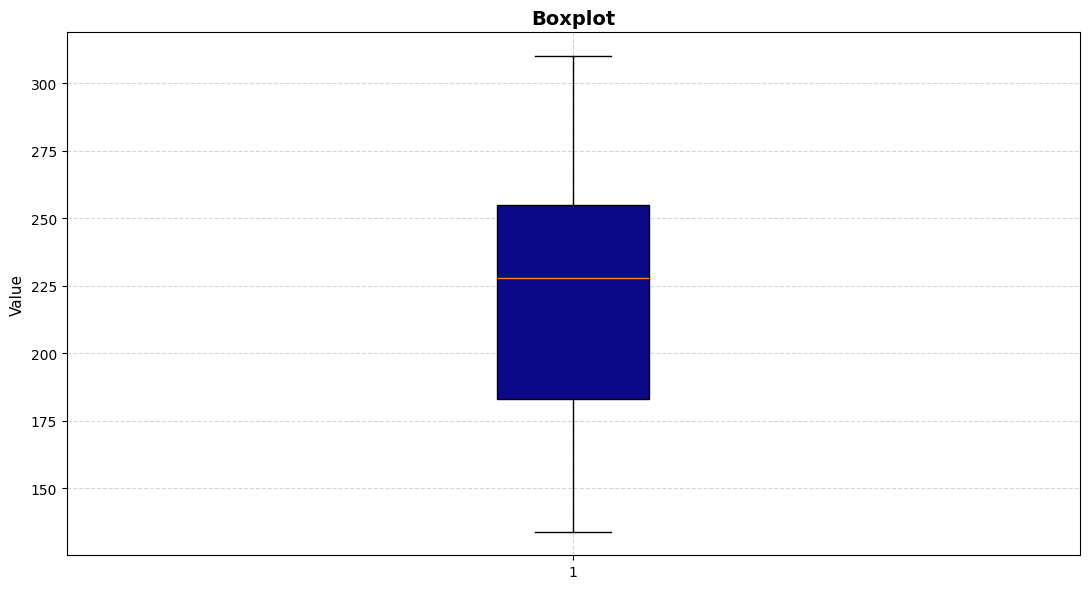

In [13]:
viz.boxplot(data=df["n_abstract_words"])

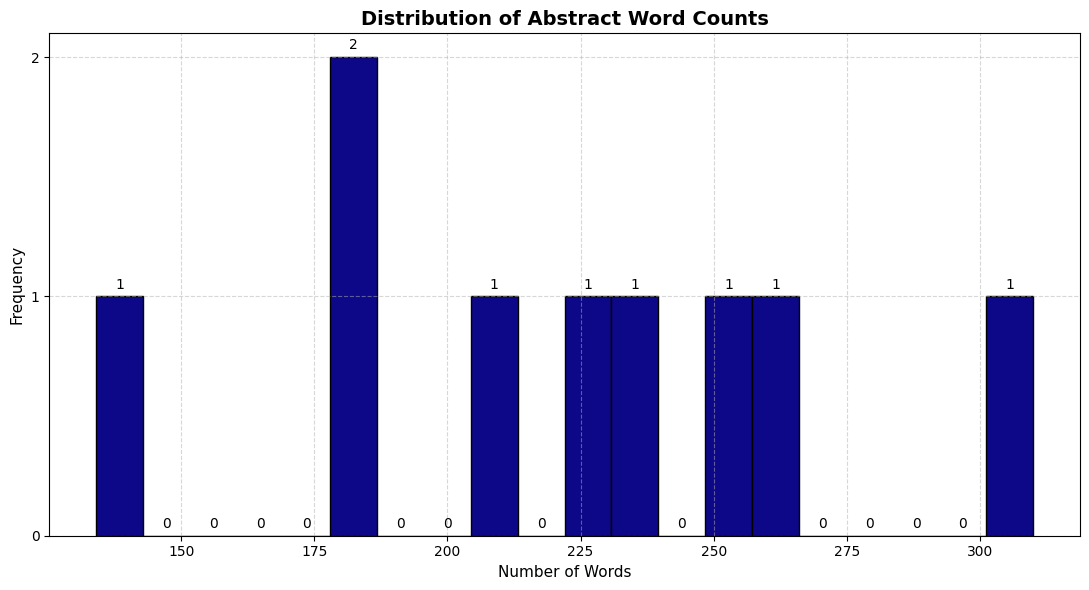

In [14]:
viz.histogram(df["n_abstract_words"], title="Distribution of Abstract Word Counts", xlabel="Number of Words")

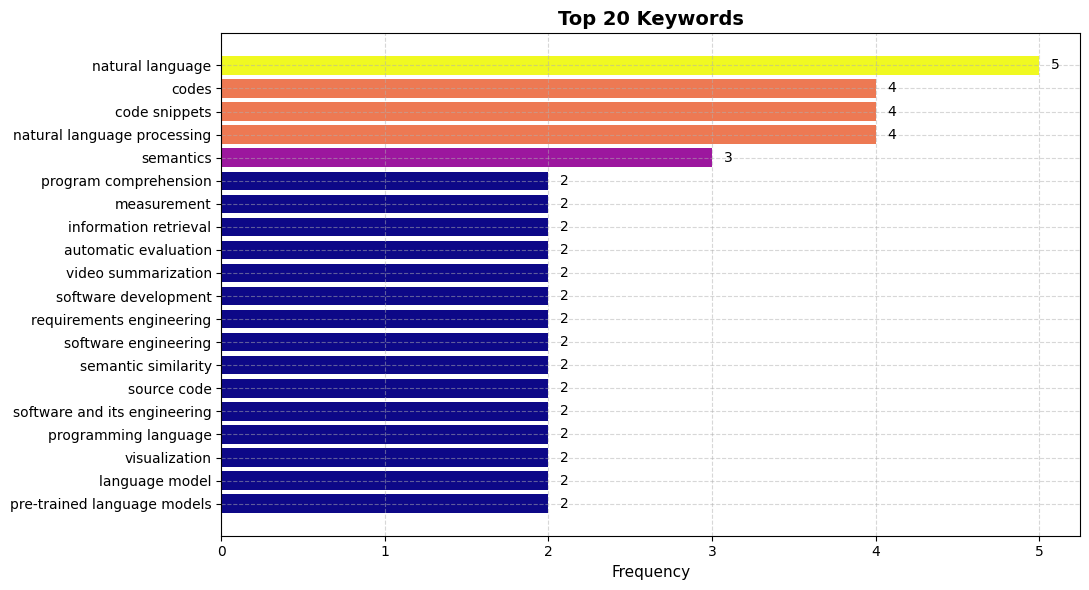

In [15]:
labels = topkw.index.tolist()
values = topkw.values.tolist()
viz.barh(labels, values, title=f"Top {len(values)} Keywords", xlabel="Frequency")


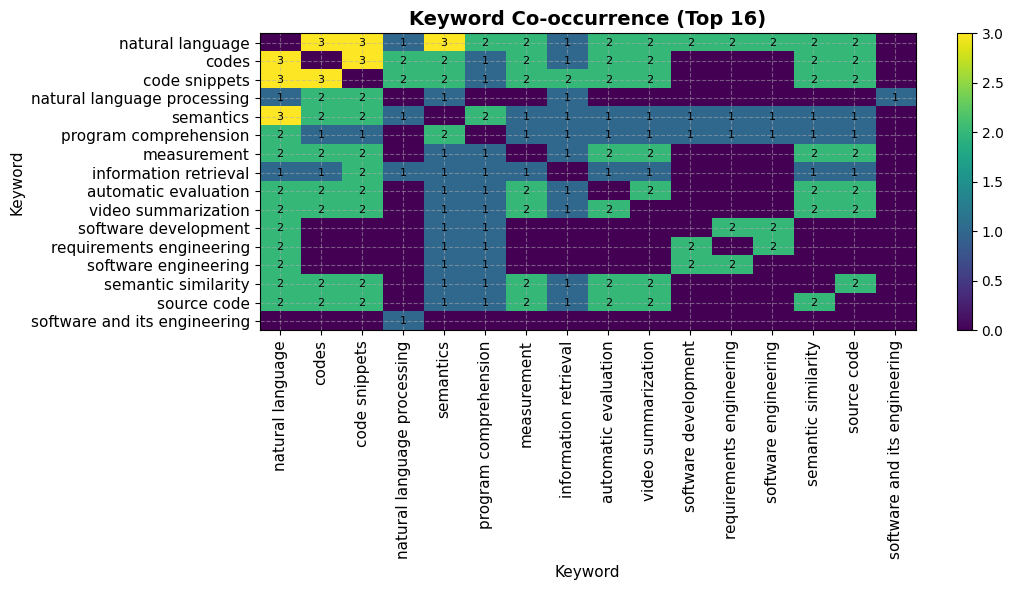

In [16]:
viz.heatmap(cooc, title="Keyword Co-occurrence (Top 16)", xlabel="Keyword", ylabel="Keyword", annotate=True)

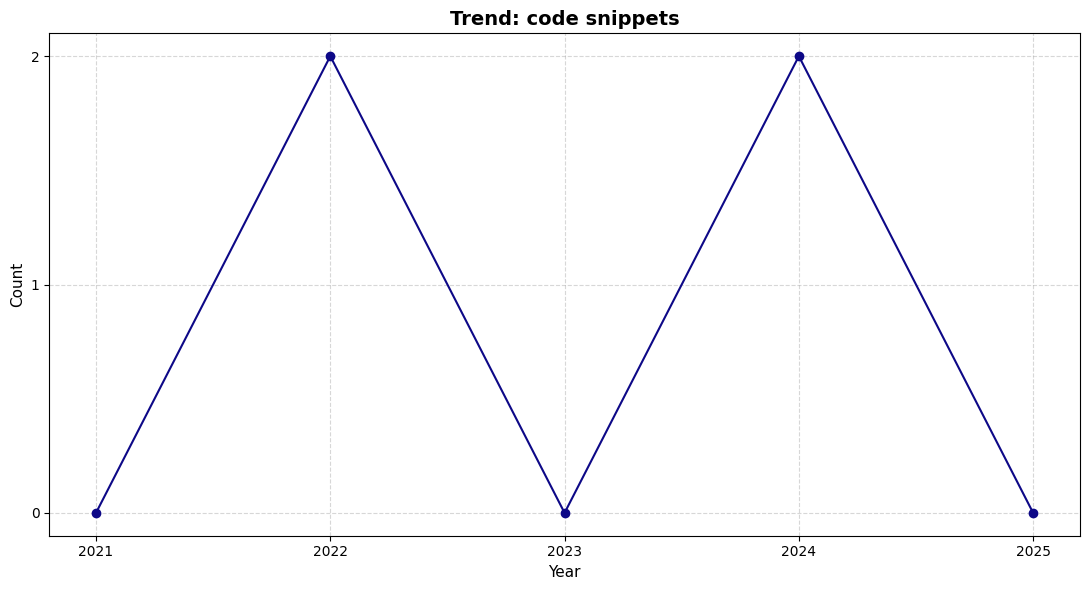

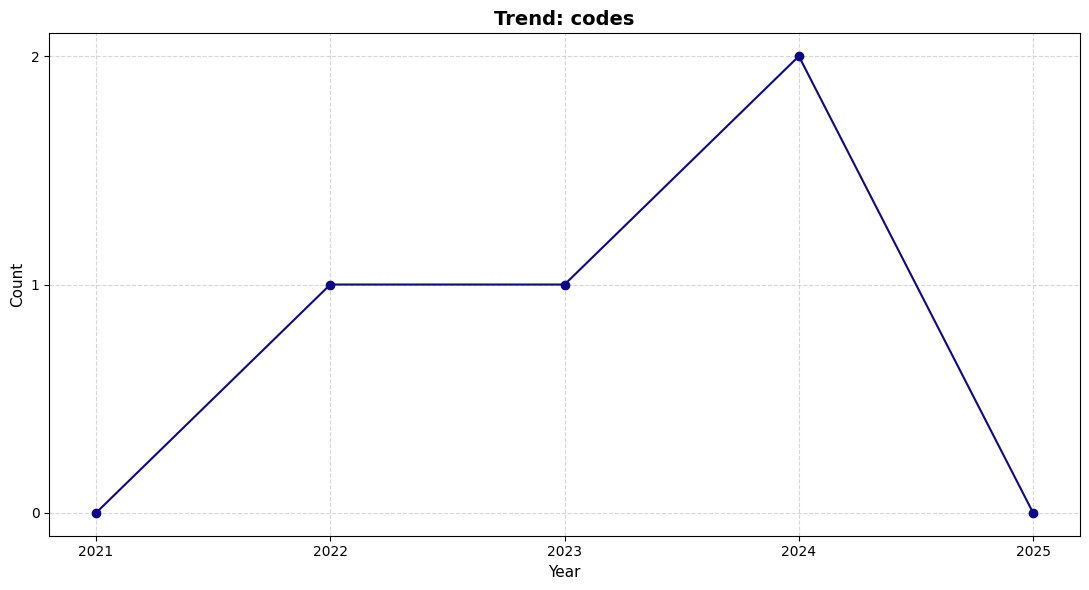

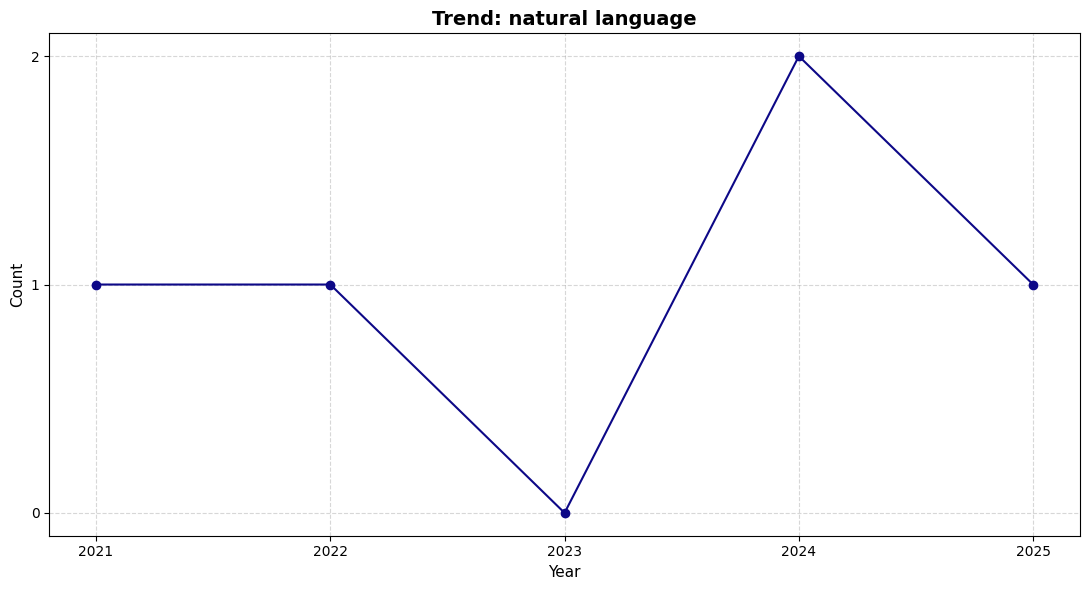

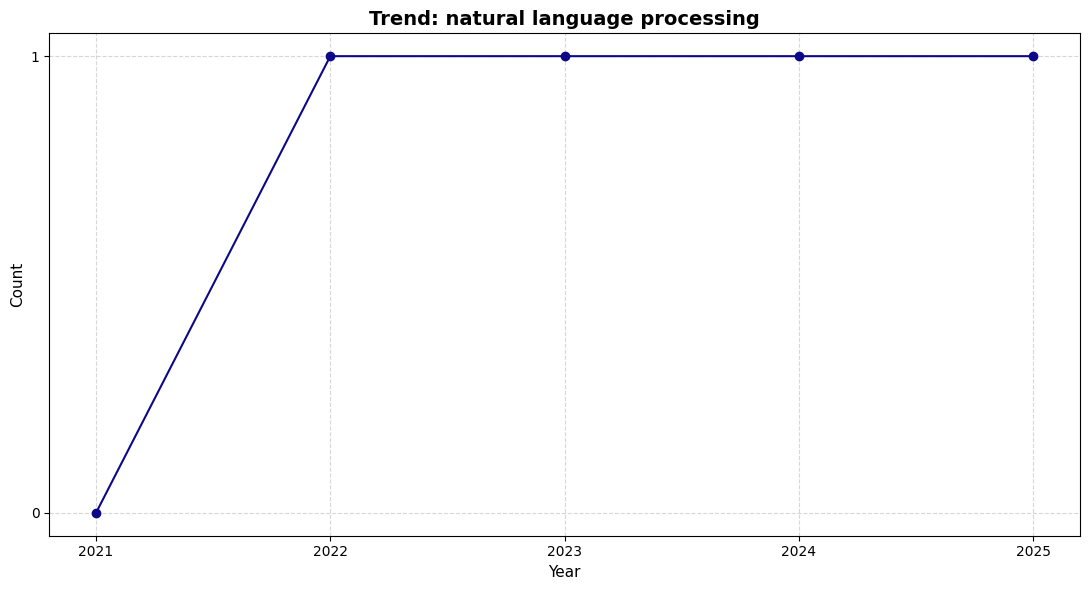

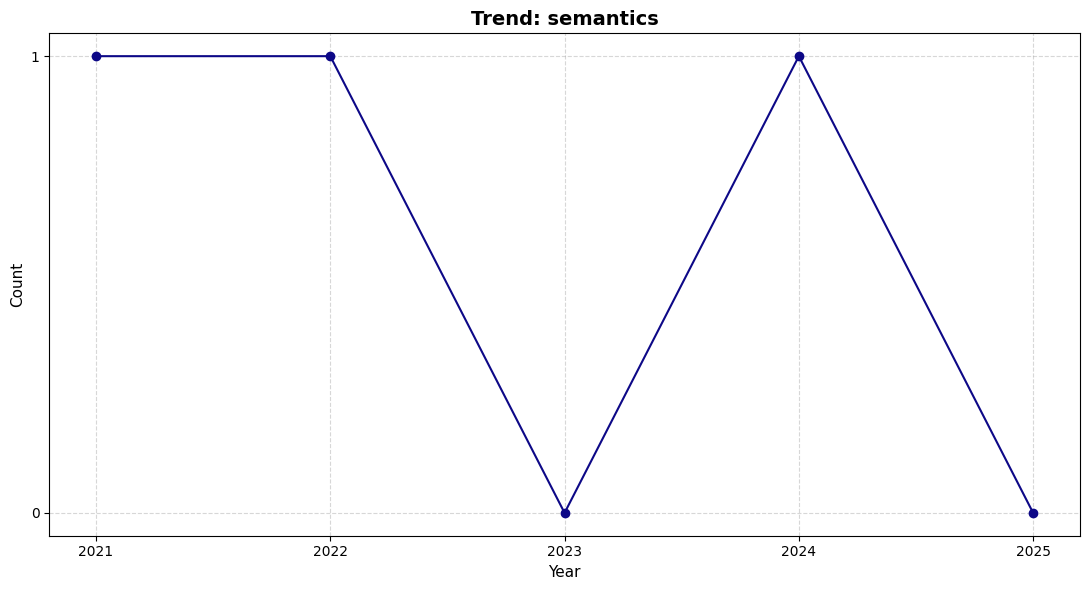

In [17]:
for kw in kw_year.columns:
    viz.line(kw_year.index, kw_year[kw].values, title=f"Trend: {kw}", xlabel="Year", ylabel="Count")

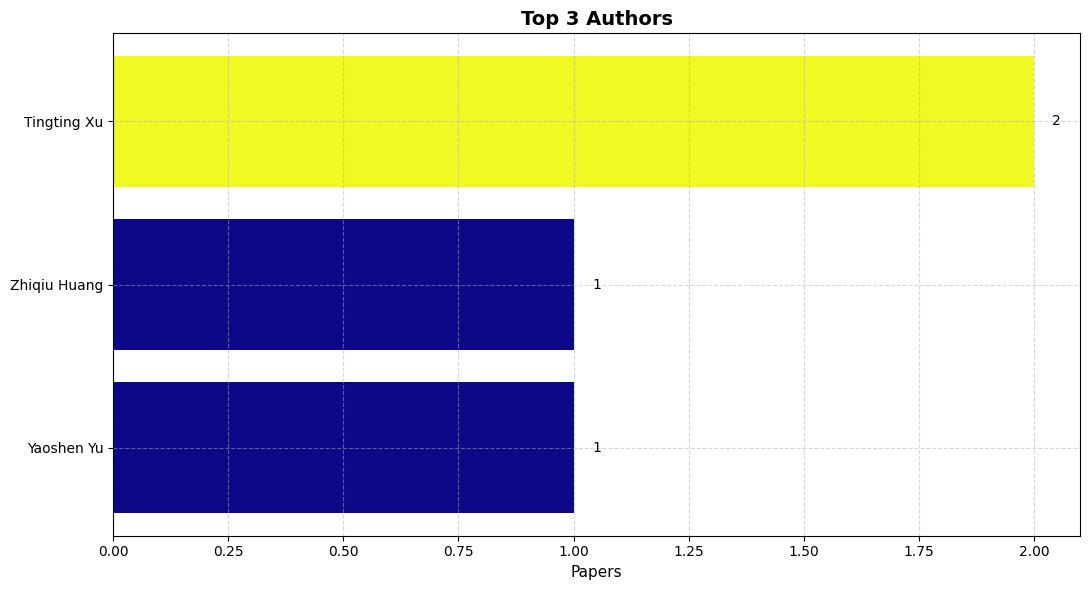

In [18]:
viz.barh(auth_top.index.tolist(), auth_top.values.tolist(),
         title=f"Top {len(auth_top)} Authors", xlabel="Papers")

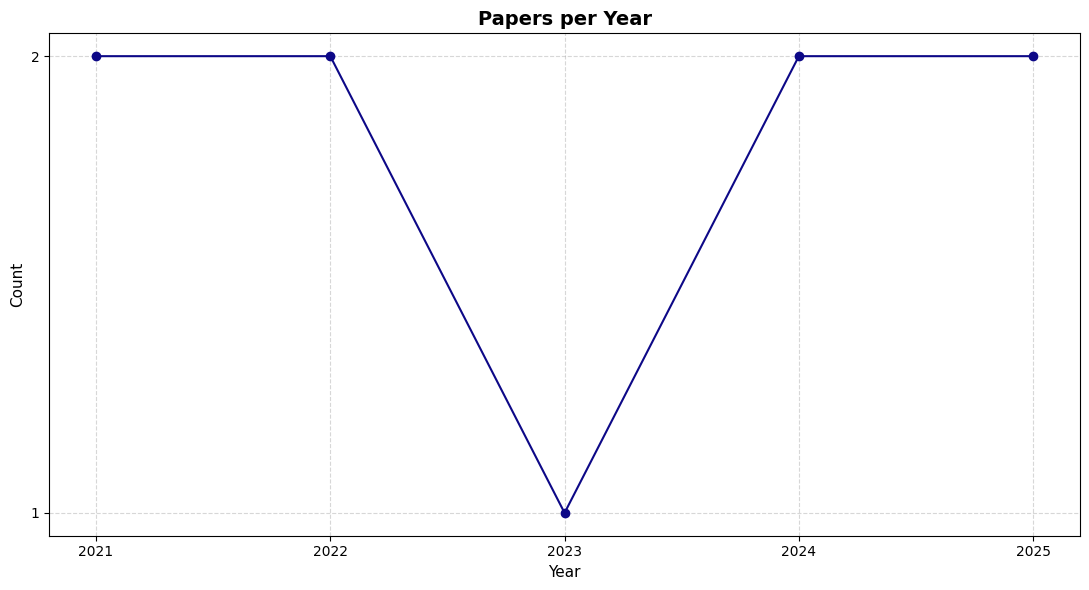

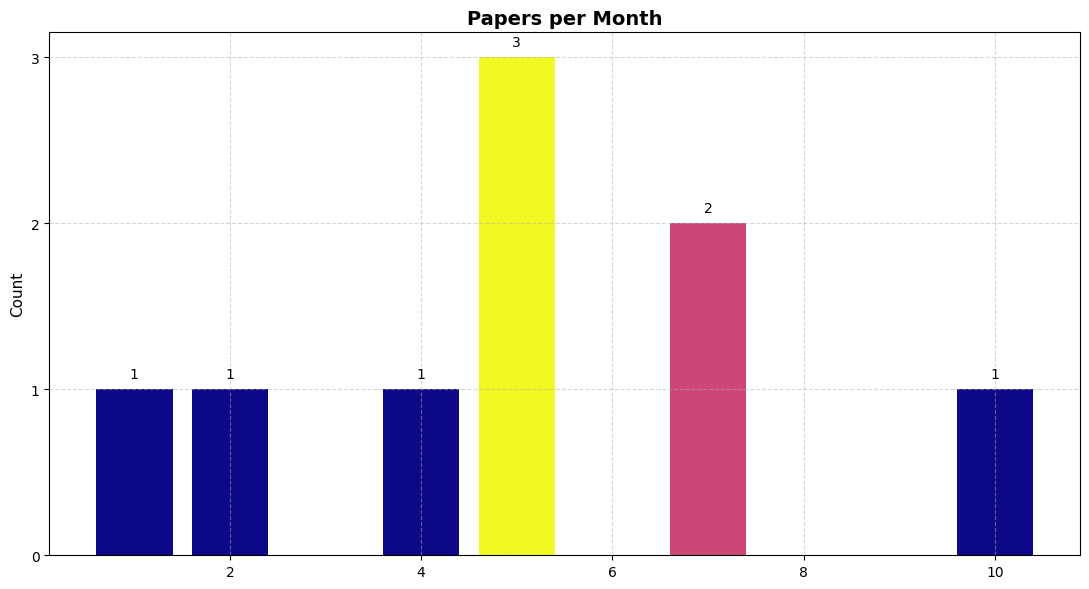

/home/kenai/projects/vscode/lisa-llm-reqs/eda/viz.py:324: FutureWarning: The provided callable <function sum at 0x73cd700c68c0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = df.groupby("dt", as_index=False)["y"].agg(aggfunc)


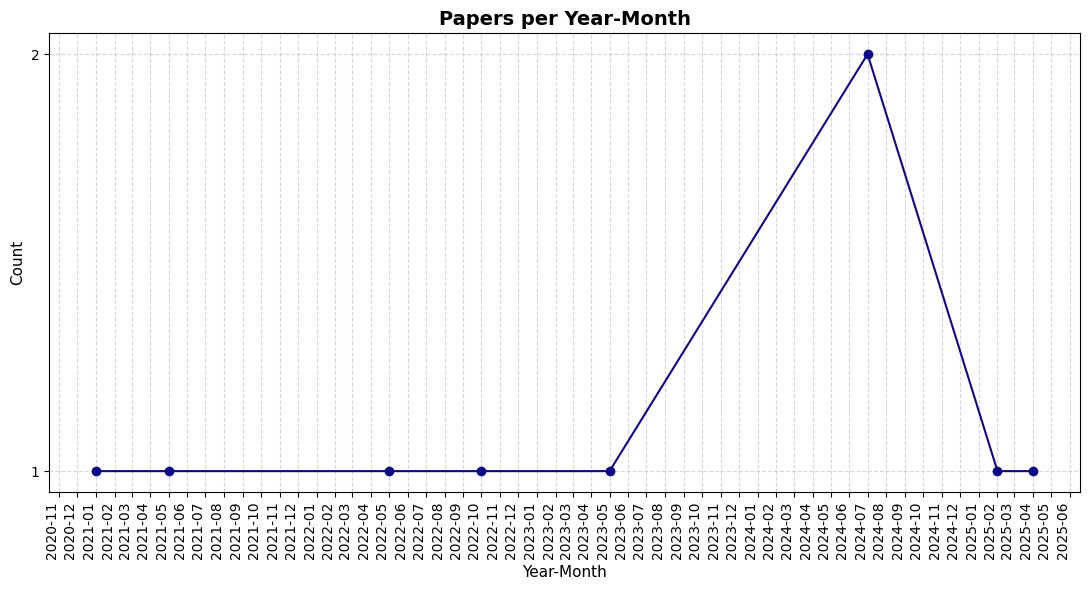

In [19]:
viz.line(yr.index.tolist(), yr.values.tolist(), title="Papers per Year", xlabel="Year", ylabel="Count")
viz.barv(mo.index.tolist(), mo.values.tolist(), title="Papers per Month", ylabel="Count")
viz.line(ym.index.tolist(), ym.values.tolist(), title="Papers per Year-Month", xlabel="Year-Month", ylabel="Count", rotation=90)

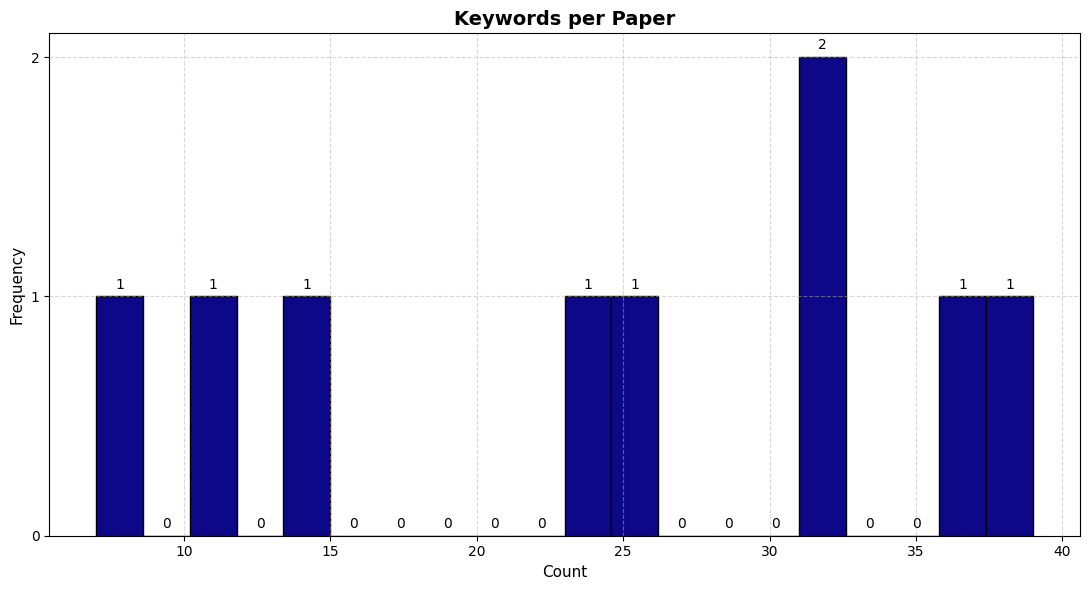

In [20]:
n_kw_per_paper = X.sum(axis=1).sort_values(ascending=False)
viz.histogram(n_kw_per_paper.values, title="Keywords per Paper", xlabel="Count")